# Tier 2 手法の解説とフル再計算 — centered_fp / rank_fp / multiband_wcl / wcl_corridor

`icsr8` パッケージに実装された Tier 2（`doc/improvement_methods_note.txt` 手法4–7）
4 手法の設計判断を一次情報（各モジュールの docstring / Why-not コメント / 上記ノート）から
解説し、Protocol A（2 fold）・LOLO（59 fold）の評価指標を **`icsr8` を import して
本ノート内でフル再計算**する。

- 乱数シードは `icsr8.constants.RANDOM_SEED`、bootstrap 反復数は `B=1000`
  （`scripts/run_all_methods.py` の非 smoke 既定と同一条件）。
- 末尾の照合セルで `results/protocol_a.csv` / `results/lolo_summary.csv` の該当行と
  `numpy.testing.assert_allclose(atol=1e-6)` で突き合わせる。
- 本ノートは `icsr8.methods.run_method` / `icsr8.harness` の公開関数 /
  `icsr8.protocols` / `icsr8.evaluate` を呼び出すのみで、推定ロジック自体は
  一切複製しない（デモセルのみ、テストコード同様に手法モジュールの private
  helper を直接呼んで中間状態を可視化する）。

対象 4 手法:

| 手法名 (登録名) | 元ネタ | uses_geometry |
|---|---|---|
| `centered_fp` | 手法4: Centered / Relative RSSI | False（指紋のみ） |
| `rank_fp` | 手法5: Rank-based Fingerprinting | False（指紋のみ） |
| `multiband_wcl` | 手法6: 周波数帯分離 + Multi-Band Fusion | True（AP 座標を使用） |
| `wcl_corridor` | 手法7: 廊下制約（Corridor Constraint） | True（AP 座標を使用） |


In [1]:
%matplotlib inline
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_notebook_start = time.time()

# notebooks/ から実行しても repo root から実行しても動くように解決する
# （baseline_reproduction.ipynb と同じ規約。os.chdir は使わない）。
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATASET_DIR = REPO / "data" / "dataset"
RAWDATA_ROOT = REPO / "data" / "rawdata"
RESULTS_DIR = REPO / "results"

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

print("REPO =", REPO)


REPO = /Users/kinoko/Development/github/icsR8


## 1. データ読み込み

`icsr8.io` の公開ローダで AP 座標（13-AP 3F 表）、正解座標、forward/backward 両方向の raw scan を読み込む。以降のセルはすべてこの4つの DataFrame から派生する。

In [2]:
from icsr8.io import load_ap_coords, load_location_coords, load_raw_scans

ap13 = load_ap_coords(DATASET_DIR / "AP_coordinate_C3F.csv")
truth = load_location_coords(DATASET_DIR / "location_coordinate_C.csv")[["location_p", "x", "y"]]
scans_f = load_raw_scans("forward", RAWDATA_ROOT)
scans_b = load_raw_scans("backward", RAWDATA_ROOT)

print(f"ap13: {ap13.shape}, truth: {truth.shape}")
print(f"scans_f: {scans_f.shape} ({scans_f['location_p'].nunique()} locations)")
print(f"scans_b: {scans_b.shape} ({scans_b['location_p'].nunique()} locations)")


ap13: (13, 5), truth: (59, 3)
scans_f: (16659, 7) (59 locations)
scans_b: (17432, 7) (59 locations)


## 2. 各手法の理論的背景

一次情報: `src/icsr8/methods/{centered_fp,rank_fp,multiband_wcl,corridor_proj}.py` の
モジュール docstring / Why-not コメントおよび `doc/improvement_methods_note.txt` 手法4–7。

### 2.1 `centered_fp`（手法4: Centered / Relative RSSI）

観測モデル `r_{s,a} = μ_{l,a} + δ_s + ε_{s,a}` の `δ_s`
（測定回・端末保持方向・身体遮蔽・端末 AGC によるスキャン全体のオフセット）を、
そのスキャンで観測された鍵集合 `O_s` の中央値で推定し除去する:

```
r̃_{s,a} = r_{s,a} - median_{j∈O_s} r_{s,j}
```

特徴空間は学習データの `(ap_name, band)` 鍵の和集合で固定し、raw 距離と centered 距離を
λ で線形補間する:

```
d² = λ · Σ_{a∈union}(r - μ)²             … raw 項（鍵和集合、-100 埋め）
   + (1-λ) · mean_{a∈O_q∩O_l}(r̃ - μ̃)²   … centered 項（両側が観測した鍵のみ、平均）
```

raw 項は鍵和集合全体（`NON_DETECT_DBM=-100` 埋め）での二乗和 — 「一方が非検出・他方が検出」
という組み合わせ自体が censored な情報を持つため保持する。centered 項は共通観測鍵
`O_q∩O_l` のみの**平均**二乗差（重なり数が異なる候補間でも比較可能にするため）で、
共通観測鍵が 3 未満の候補は raw 項で代用する（`+inf` にすると候補プールを静かに空にしうるため）。

λ は inner CV（location 単位 5-fold、`RANDOM_SEED` 固定）で
`{0.0, 0.25, 0.5, 0.75, 1.0}` から選択する（同点は大きい λ を優先）。
K=3 最近傍の逆距離二乗重み centroid で推定する（baseline WCL の top-3 と条件を揃える）。
`uses_geometry=False` — AP 座標未知の AP も含め、全 AP の指紋のみで動く。

### 2.2 `rank_fp`（手法5: Rank-based Fingerprinting）

AP 強度の絶対値ではなく**順位**（強い順、同値は average rank）を使うため、加法オフセット
`δ_s` に完全不変。共通観測鍵 `O_q∩O_l` 上で Spearman footrule 距離と RSSI 二乗距離を
λ で混合する:

```
d_rank(q,l) = Σ_{a∈O_q∩O_l} |rank_q(a) - rank_l(a)|  / normalizer,  normalizer = ⌊|O|²/2⌋
d_hybrid    = λ · d_rssi_norm + (1-λ) · d_rank
```

`d_rssi_norm` はクエリの候補集合内で最大値により正規化した平均二乗差（dB² と rank 単位は
無関係な尺度なので、λ が意味を持つにはクエリごとに相対スケールを揃える必要がある）。
どの DB 地点とも `|O_q∩O_l| < 3` で候補集合が空になる場合は、鍵和集合上の raw-RSSI
Euclidean 距離に fallback する（`rank_fallback_count` に発動回数を記録）。
λ は train のみを使う inner CV（k=5）でグリッド選択する。K=3 最近傍の逆距離二乗重み
centroid で推定する。`uses_geometry=False`。

### 2.3 `multiband_wcl`（手法6: 周波数帯分離 + Multi-Band Fusion）

フリスの伝達公式 `ΔL = 20·log₁₀(f/f₀)` より 2.4/5/6 GHz 帯は経路損失が
（2.4→6GHz で理論上 ~8 dB、実測例では path-loss exponent > 2 を示唆する ~13 dB）異なるため、
帯域を混ぜたまま単一の WCL に投入すると重みが歪む。

1. 帯域ごとに独立な対数距離減衰モデルを学習データから最小二乗フィット:
   `rssi = P0 - 10α·log10(d)`（`d` は AP-地点距離、0.5 m でクリップ）。
2. 各帯の WCL を **train 地点に対して実行**（リークなし）し、真値との位置 MSE
   `mse_b` を得る。融合重みは `w_b = 1/max(mse_b, 0.01)`（使える train 地点が 3 未満の
   帯は重み 0 で融合から除外）。
3. predict では帯域ごとに（候補 ≥3 の帯のみ）baseline WCL を実行し、`w_b` による
   逆分散重み付き平均で統合する。融合可能な帯が無ければ 13-AP 全体の pooled baseline WCL
   に fallback する。

dB 残差 `σ_b`（`band_sigma`）は同じ dB 誤差でも帯ごとに位置誤差への影響が異なり位置不確かさの
代理として不適切なため、融合には使わず診断値としてのみ保持する。`uses_geometry=True`。

### 2.4 `wcl_corridor`（手法7: 廊下制約）

推定 `(x, y)` を、既知の L 字廊下の区分線形経路へ事後的に射影する後処理:

```
Segment C  (32, 0) → (0, 0)    東西方向
Segment C2 (0, 0)  → (0, 56)   南北方向
Segment C3 (0, 56) → (28, 56)  東西方向
```

`apply_corridor_projection` は任意メソッドの推定 DataFrame に適用できる汎用の純関数で、
`wcl_corridor` は baseline WCL にこれを適用した登録メソッド。角部では射影しても
廊下方向成分の誤差は解決しない（例: `doc/improvement_methods_note.txt` 手法7の
P17 の例では射影後も 11 m 級の誤差が残る）。`uses_geometry=True`。


## 3. 各手法のデモ

推定ロジックを再実装せず、各手法モジュールの関数（テストコードと同様に private helper も含む）を直接呼んで中間状態を可視化する。

### 3.1 `centered_fp`: オフセット除去前後の距離

forward 方向を DB、backward 方向をクエリとして、同一地点に対する **raw 距離**（λ=1）と **centered 距離**（λ=0）を比較する。往路/復路間には端末保持方向・身体遮蔽由来の スキャン全体オフセット `δ_s` があるため、raw 距離では真の対応地点の順位が下がるが、centered 距離ではオフセットが打ち消され順位が改善する地点を探して例示する。

In [3]:
from icsr8.methods.centered_fp import _build_matrix_masked, _distance_sq

keys, locs, raw_db, cen_db, obs_db = _build_matrix_masked(scans_f)
_, locs_q, raw_q, cen_q, obs_q = _build_matrix_masked(scans_b, keys=keys)

# raw では真の対応地点の順位が悪いが centered では改善する例を探す
demo_loc = None
for cand in sorted(set(locs) & set(locs_q)):
    qi, di = locs_q.index(cand), locs.index(cand)
    d_raw = _distance_sq(raw_q[qi], cen_q[qi], obs_q[qi], raw_db, cen_db, obs_db, lam=1.0)
    d_cen = _distance_sq(raw_q[qi], cen_q[qi], obs_q[qi], raw_db, cen_db, obs_db, lam=0.0)
    rank_raw = int((d_raw < d_raw[di]).sum()) + 1
    rank_cen = int((d_cen < d_cen[di]).sum()) + 1
    if rank_raw > 3 and rank_cen == 1:
        demo_loc = cand
        break

qi, di = locs_q.index(demo_loc), locs.index(demo_loc)
d_raw = _distance_sq(raw_q[qi], cen_q[qi], obs_q[qi], raw_db, cen_db, obs_db, lam=1.0)
d_cen = _distance_sq(raw_q[qi], cen_q[qi], obs_q[qi], raw_db, cen_db, obs_db, lam=0.0)
rank_raw = int((d_raw < d_raw[di]).sum()) + 1
rank_cen = int((d_cen < d_cen[di]).sum()) + 1

print(f"demo location_p = {demo_loc} (backward query vs forward DB, {len(locs)} DB locations)")
print(f"  raw (λ=1)      d² to true match = {d_raw[di]:8.1f}   rank = {rank_raw} / {len(locs)}")
print(f"  centered (λ=0) d² to true match = {d_cen[di]:8.1f}   rank = {rank_cen} / {len(locs)}")
print("  -> raw 距離では方向オフセットのせいで真の対応地点が上位候補から外れるが、"
      "\n     centered 距離はオフセットを打ち消し 1 位に戻す。")


demo location_p = 10 (backward query vs forward DB, 59 DB locations)
  raw (λ=1)      d² to true match =   2957.5   rank = 5 / 59
  centered (λ=0) d² to true match =     25.6   rank = 1 / 59
  -> raw 距離では方向オフセットのせいで真の対応地点が上位候補から外れるが、
     centered 距離はオフセットを打ち消し 1 位に戻す。


### 3.2 `rank_fp`: 順位ベクトル

1 地点の指紋を RSSI 強度順（rank 1 = 最強）に並べ替えた順位ベクトルを表示する。

In [4]:
from icsr8.methods.rank_fp import _build_db, _rerank

db = _build_db(scans_f)
demo_loc_rank = sorted(db)[0]
fp = db[demo_loc_rank]
rank_keys = sorted(fp)
vals = np.array([fp[k] for k in rank_keys])
ranks = _rerank(vals)

rank_table = pd.DataFrame({
    "ap_name": [k[0] for k in rank_keys],
    "band": [k[1] for k in rank_keys],
    "rssi_median": vals,
    "rank": ranks,
}).sort_values("rank").reset_index(drop=True)

print(f"demo location_p = {demo_loc_rank}, n_keys = {len(rank_keys)}")
rank_table.head(10)


demo location_p = 1, n_keys = 25


,ap_name,band,rssi_median,rank
0,AP-C0-3F-01,2.4G,-42.0,1.0
1,AP-C0-3F-02,2.4G,-54.0,2.0
2,AP-C0-3F-01,6G,-55.0,3.0
3,AP-C0-3F-01,5G,-56.0,4.0
4,AP-C0-3F-02,5G,-57.0,5.5
5,AP-C1-3F-01,2.4G,-57.0,5.5
6,AP-C0-4F-02,2.4G,-63.0,7.0
7,AP-C1-3F-01,5G,-64.0,8.5
8,AP-C0-4F-01,2.4G,-64.0,8.5
9,AP-C0-3F-03,6G,-65.0,10.0


### 3.3 `multiband_wcl`: 帯域別重み

forward プール全体で fit し、帯域別の位置 MSE・融合重み `w_b = 1/max(mse_b, 0.01)`・診断用の dB 残差 `σ_b` を並べる。

In [5]:
from icsr8.methods.multiband_wcl import MultibandWcl

demo_mbw = MultibandWcl().fit(scans_f, ap13, truth[truth["location_p"].isin(scans_f["location_p"].unique())])

band_table = pd.DataFrame({
    "band_mse": demo_mbw.band_mse,
    "band_weight": demo_mbw.band_weights,
    "band_sigma_db (diagnostic only)": demo_mbw.band_sigma,
}).sort_index()
print(f"n_path_loss_fits (ap_name, band) = {len(demo_mbw.path_loss_fits)}")
band_table


n_path_loss_fits (ap_name, band) = 28

,band_mse,band_weight,band_sigma_db (diagnostic only)
2.4G,18.958291,0.052747,6.407141
5G,35.057211,0.028525,7.009073
6G,139.255919,0.007181,5.939829


### 3.4 `wcl_corridor`: 射影前後

backward スキャンに baseline WCL を適用した生の推定 `(x_raw, y_raw)` と、廊下へ射影した `(x_proj, y_proj)` を比較し、射影による移動量が大きい上位 5 地点を示す。

In [6]:
from icsr8.estimators import estimate_wcl
from icsr8.fingerprint import candidate_medians, reproduction_fingerprint
from icsr8.methods.corridor_proj import apply_corridor_projection

fp_b = reproduction_fingerprint(candidate_medians(scans_b, ap13))
raw_est = estimate_wcl(fp_b)
proj_est = apply_corridor_projection(raw_est)

compare = raw_est.merge(proj_est, on="location_p", suffixes=("_raw", "_proj"))
compare["shift_m"] = np.hypot(
    compare["x_raw"] - compare["x_proj"], compare["y_raw"] - compare["y_proj"]
)
compare.sort_values("shift_m", ascending=False).head(5).reset_index(drop=True)


,location_p,x_raw,y_raw,x_proj,y_proj,shift_m
0,43,2.832575,50.114273,0.000000,50.114273,2.832575
1,57,25.630312,57.290031,25.630312,56.000000,1.290031
2,58,25.532934,57.277843,25.532934,56.000000,1.277843
3,59,25.192398,57.223592,25.192398,56.000000,1.223592
4,41,1.198235,43.798212,0.000000,43.798212,1.198235


## 4. Protocol A（2 fold）フル計算

`icsr8.harness.run_protocol_a` を呼ぶ。`delta_vs_wcl`（baseline WCL とのペア差分 bootstrap）
を Tier 2 各手法について計算するには、同一 fold の `wcl` 台帳が必要なので、
methods リストに `"wcl"` を含めて一度に流す（Tier 2 4 手法の結果自体には影響しない —
`_paired_delta` は該当手法と `wcl` の台帳のみを参照する）。

In [7]:
from icsr8.constants import RANDOM_SEED
from icsr8.harness import run_lolo, run_protocol_a

METHODS_TIER2 = ["centered_fp", "rank_fp", "multiband_wcl", "wcl_corridor"]
METHODS_FOR_PROTOCOL_A = METHODS_TIER2 + ["wcl"]  # delta_vs_wcl の基準台帳として必要

t0 = time.time()
protocol_a_results, protocol_a_ledgers = run_protocol_a(
    METHODS_FOR_PROTOCOL_A, scans_f, scans_b, ap13, truth, seed=RANDOM_SEED, B=1000
)
t_protocol_a = time.time() - t0

protocol_a_tier2 = protocol_a_results[protocol_a_results["method"].isin(METHODS_TIER2)].reset_index(drop=True)
print(f"Protocol A elapsed: {t_protocol_a:.1f} s")
protocol_a_tier2


Protocol A elapsed: 3.2 s


,method,fold,ave,median,p75,p90,max,std,within_2m,within_4m,ci_lo,ci_hi,delta_vs_wcl,delta_lo,delta_hi,failed
0,centered_fp,forward_to_backward,1.368966,0.795817,1.805449,3.943743,6.719983,1.611938,0.813559,0.898305,0.981324,1.796880,-2.143533,-2.896978,-1.317776,False
1,rank_fp,forward_to_backward,1.366289,0.462392,1.624384,2.024330,31.628105,4.088853,0.881356,0.949153,0.666511,2.592061,-2.146209,-3.180617,-0.589350,False
2,multiband_wcl,forward_to_backward,3.809417,3.466666,4.820689,6.431998,11.078957,2.292613,0.203390,0.644068,3.251622,4.368377,0.296918,-0.096271,0.681958,False
3,wcl_corridor,forward_to_backward,3.314042,2.765552,4.747591,6.003138,12.154501,2.643527,0.406780,0.694915,2.648168,3.971934,-0.198457,-0.272657,-0.139078,False
4,centered_fp,backward_to_forward,1.394789,1.431777,1.990491,2.702098,5.969325,1.334975,0.745763,0.949153,1.081637,1.761108,-2.173754,-2.815435,-1.552159,False
5,rank_fp,backward_to_forward,1.644787,0.674037,1.737736,2.786553,19.242189,3.006418,0.796610,0.932203,0.973504,2.537580,-1.923756,-2.580167,-1.167072,False
6,multiband_wcl,backward_to_forward,3.720949,3.209833,4.742224,7.374893,12.989543,2.687434,0.305085,0.627119,3.082340,4.428275,0.152406,-0.076324,0.396594,False
7,wcl_corridor,backward_to_forward,3.315350,3.090814,4.409754,6.437537,11.811643,2.576507,0.389831,0.677966,2.697268,3.982851,-0.253193,-0.392760,-0.155711,False


## 5. LOLO（59 fold）フル計算

`icsr8.harness.run_lolo` を Tier 2 4 手法のみで回す（LOLO summary は手法ごとに独立な
決定的統計のみで `wcl` 台帳を参照しないため `"wcl"` は不要）。

In [8]:
t0 = time.time()
lolo_ledger, lolo_summary = run_lolo(
    METHODS_TIER2, scans_f, scans_b, ap13, truth, seed=RANDOM_SEED
)
t_lolo = time.time() - t0

print(f"LOLO elapsed: {t_lolo:.1f} s ({lolo_ledger['held_out'].nunique()} folds x {len(METHODS_TIER2)} methods)")
lolo_summary


[harness] lolo centered_fp fold 1/59 (held_out=1)
[harness] lolo centered_fp fold 2/59 (held_out=2)


[harness] lolo centered_fp fold 3/59 (held_out=3)
[harness] lolo centered_fp fold 4/59 (held_out=4)


[harness] lolo centered_fp fold 5/59 (held_out=5)
[harness] lolo centered_fp fold 6/59 (held_out=6)


[harness] lolo centered_fp fold 7/59 (held_out=7)
[harness] lolo centered_fp fold 8/59 (held_out=8)


[harness] lolo centered_fp fold 9/59 (held_out=9)
[harness] lolo centered_fp fold 10/59 (held_out=10)


...

[harness] lolo multiband_wcl fold 57/59 (held_out=57)
[harness] lolo multiband_wcl fold 58/59 (held_out=58)


[harness] lolo multiband_wcl fold 59/59 (held_out=59)
[harness] lolo wcl_corridor fold 1/59 (held_out=1)
[harness] lolo wcl_corridor fold 2/59 (held_out=2)
[harness] lolo wcl_corridor fold 3/59 (held_out=3)
[harness] lolo wcl_corridor fold 4/59 (held_out=4)
[harness] lolo wcl_corridor fold 5/59 (held_out=5)
[harness] lolo wcl_corridor fold 6/59 (held_out=6)
[harness] lolo wcl_corridor fold 7/59 (held_out=7)
[harness] lolo wcl_corridor fold 8/59 (held_out=8)
[harness] lolo wcl_corridor fold 9/59 (held_out=9)
[harness] lolo wcl_corridor fold 10/59 (held_out=10)
[harness] lolo wcl_corridor fold 11/59 (held_out=11)


LOLO elapsed: 76.4 s (59 folds x 4 methods)


[harness] lolo wcl_corridor fold 12/59 (held_out=12)
[harness] lolo wcl_corridor fold 13/59 (held_out=13)
[harness] lolo wcl_corridor fold 14/59 (held_out=14)
[harness] lolo wcl_corridor fold 15/59 (held_out=15)
[harness] lolo wcl_corridor fold 16/59 (held_out=16)
[harness] lolo wcl_corridor fold 17/59 (held_out=17)
[harness] lolo wcl_corridor fold 18/59 (held_out=18)
[harness] lolo wcl_corridor fold 19/59 (held_out=19)
[harness] lolo wcl_corridor fold 20/59 (held_out=20)
[harness] lolo wcl_corridor fold 21/59 (held_out=21)
[harness] lolo wcl_corridor fold 22/59 (held_out=22)
[harness] lolo wcl_corridor fold 23/59 (held_out=23)
[harness] lolo wcl_corridor fold 24/59 (held_out=24)
[harness] lolo wcl_corridor fold 25/59 (held_out=25)
[harness] lolo wcl_corridor fold 26/59 (held_out=26)
[harness] lolo wcl_corridor fold 27/59 (held_out=27)
[harness] lolo wcl_corridor fold 28/59 (held_out=28)
[harness] lolo wcl_corridor fold 29/59 (held_out=29)
[harness] lolo wcl_corridor fold 30/59 (held_o

,method,ave,median,p90,within_2m
0,centered_fp,2.082354,1.373097,4.113937,0.711864
1,rank_fp,2.704579,1.346275,3.880381,0.762712
2,multiband_wcl,3.815848,3.485321,6.445503,0.203390
3,wcl_corridor,3.314042,2.765552,6.003138,0.406780


### LOLO 誤差 CDF

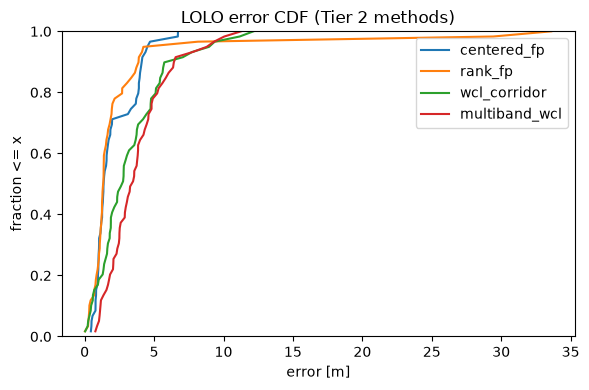

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
order = lolo_ledger.groupby("method")["error"].mean().sort_values().index.tolist()
for method in order:
    errs = np.sort(lolo_ledger.loc[lolo_ledger["method"] == method, "error"].dropna().to_numpy(dtype=float))
    y = np.arange(1, len(errs) + 1) / len(errs)
    ax.plot(errs, y, label=method)
ax.set_xlabel("error [m]")
ax.set_ylabel("fraction <= x")
ax.set_ylim(0.0, 1.0)
ax.set_title("LOLO error CDF (Tier 2 methods)")
ax.legend()
fig.tight_layout()
plt.show()


## 6. 診断値

`scripts/dump_method_diagnostics.py` と同じ条件（FULL forward プール: `train_scans=scans_f`
の 59 地点全て、`location_coords=truth` 59 地点全て）で `centered_fp` / `rank_fp` を fit し、
inner CV で選択された λ を表示する。`results/method_diagnostics.csv`
（凍結済み・読み取り専用で参照するのみ）の値と突き合わせる。

In [10]:
from icsr8.methods import REGISTRY

cfp_full = REGISTRY["centered_fp"]().fit(scans_f, ap13, truth)
rfp_full = REGISTRY["rank_fp"]().fit(scans_f, ap13, truth)

ref_diag = pd.read_csv(RESULTS_DIR / "method_diagnostics.csv")


def _ref(method: str, key: str) -> float:
    row = ref_diag[(ref_diag["method"] == method) & (ref_diag["key"] == key)]
    return float(row["value"].iloc[0])


print(f"centered_fp.selected_lambda = {cfp_full.selected_lambda}  "
      f"(results/method_diagnostics.csv = {_ref('centered_fp', 'selected_lambda')})")
print(f"rank_fp._lambda              = {rfp_full._lambda}  "
      f"(results/method_diagnostics.csv = {_ref('rank_fp', 'selected_lambda')})")

assert cfp_full.selected_lambda == _ref("centered_fp", "selected_lambda")
assert rfp_full._lambda == _ref("rank_fp", "selected_lambda")
print("-> method_diagnostics.csv と一致（診断値、参考確認）")


centered_fp.selected_lambda = 0.25  (results/method_diagnostics.csv = 0.25)
rank_fp._lambda              = 0.75  (results/method_diagnostics.csv = 0.75)
-> method_diagnostics.csv と一致（診断値、参考確認）


In [11]:
print("multiband_wcl band_weights (full forward pool fit, §3.3 と同一):")
print(demo_mbw.band_weights)
print()
print("wcl_corridor: チューニング可能なハイパーパラメータなし"
      "（baseline WCL + 決定的な射影のみ）。")


multiband_wcl band_weights (full forward pool fit, §3.3 と同一):
{'2.4G': 0.05274737018603509, '5G': 0.028524801782520755, '6G': 0.007181023297660053}

wcl_corridor: チューニング可能なハイパーパラメータなし（baseline WCL + 決定的な射影のみ）。


## 7. 照合セル（必須）

上で計算した Protocol A / LOLO の Tier 2 4 手法分の結果を、凍結済みの
`results/protocol_a.csv` / `results/lolo_summary.csv`（読み取り専用で参照するのみ、
本ノートからは一切書き込まない）の該当行と `atol=1e-6` で突き合わせる。

In [12]:
PA_NUMERIC_COLS = [
    "ave", "median", "p75", "p90", "max", "std",
    "within_2m", "within_4m", "ci_lo", "ci_hi",
    "delta_vs_wcl", "delta_lo", "delta_hi",
]
LOLO_NUMERIC_COLS = ["ave", "median", "p90", "within_2m"]

# --- Protocol A ---
ref_pa = pd.read_csv(RESULTS_DIR / "protocol_a.csv")
ref_pa_tier2 = (
    ref_pa[ref_pa["method"].isin(METHODS_TIER2)]
    .sort_values(["method", "fold"])
    .reset_index(drop=True)
)
computed_pa_tier2 = (
    protocol_a_tier2.sort_values(["method", "fold"]).reset_index(drop=True)
)

assert list(computed_pa_tier2["method"]) == list(ref_pa_tier2["method"])
assert list(computed_pa_tier2["fold"]) == list(ref_pa_tier2["fold"])
assert list(computed_pa_tier2["failed"]) == list(ref_pa_tier2["failed"])
np.testing.assert_allclose(
    computed_pa_tier2[PA_NUMERIC_COLS].to_numpy(dtype=float),
    ref_pa_tier2[PA_NUMERIC_COLS].to_numpy(dtype=float),
    atol=1e-6,
)
print("Protocol A (centered_fp / rank_fp / multiband_wcl / wcl_corridor): 一致")

# --- LOLO ---
ref_lolo = pd.read_csv(RESULTS_DIR / "lolo_summary.csv")
ref_lolo_tier2 = (
    ref_lolo[ref_lolo["method"].isin(METHODS_TIER2)]
    .sort_values("method")
    .reset_index(drop=True)
)
computed_lolo_tier2 = lolo_summary.sort_values("method").reset_index(drop=True)

assert list(computed_lolo_tier2["method"]) == list(ref_lolo_tier2["method"])
np.testing.assert_allclose(
    computed_lolo_tier2[LOLO_NUMERIC_COLS].to_numpy(dtype=float),
    ref_lolo_tier2[LOLO_NUMERIC_COLS].to_numpy(dtype=float),
    atol=1e-6,
)
print("LOLO (centered_fp / rank_fp / multiband_wcl / wcl_corridor): 一致")


Protocol A (centered_fp / rank_fp / multiband_wcl / wcl_corridor): 一致
LOLO (centered_fp / rank_fp / multiband_wcl / wcl_corridor): 一致


## 8. 所要時間の記録

In [13]:
_notebook_elapsed = time.time() - _notebook_start
print(f"Protocol A (5 methods incl. wcl, 2 folds, B=1000): {t_protocol_a:.1f} s")
print(f"LOLO (4 methods, 59 folds):                        {t_lolo:.1f} s")
print(f"ノート全体の実行時間:                                {_notebook_elapsed:.1f} s "
      f"({_notebook_elapsed / 60:.1f} min)")


Protocol A (5 methods incl. wcl, 2 folds, B=1000): 3.2 s
LOLO (4 methods, 59 folds):                        76.4 s
ノート全体の実行時間:                                81.5 s (1.4 min)
